In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arch

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [313]:
df = pd.read_excel('/content/Price_dataset.xlsx', index_col='Date', parse_dates=True)

In [314]:
df.index = pd.to_datetime(df.index, format='%b-%y')
df = df.asfreq('MS')

In [315]:
df.head()

,Gram,Moong,Arhar
Date,,,
2014-01-01,103.6,126.5,118.1
2014-02-01,101.7,129.3,118.4
2014-03-01,103.5,132.6,119.0
2014-04-01,102.8,135.5,120.6
2014-05-01,103.1,137.8,121.0


In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


# Descriptive statistics

<Axes: xlabel='Date'>

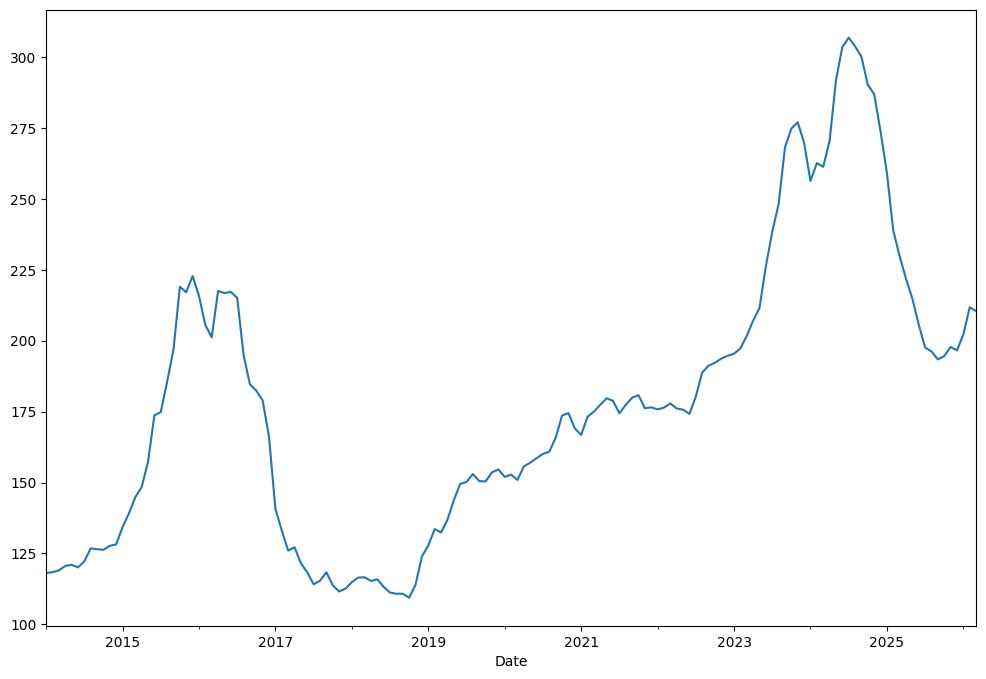

In [317]:
df['Arhar'].plot(figsize=(12,8))

In [318]:
df['Arhar'].describe()

,Arhar
count,147.000000
mean,178.121088
std,50.720641
min,109.400000
25%,133.350000
50%,175.700000
75%,205.550000
max,306.800000


In [319]:
df['Arhar'].skew()

np.float64(0.6816612491307928)

In [320]:
df['Arhar'].kurtosis()

np.float64(-0.15005163503447383)

## Decompose the series

In [321]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [322]:
decompose = seasonal_decompose(df['Arhar'], model='add')

In [323]:
decompose.seasonal

,seasonal
Date,
2014-01-01,-3.331000
2014-02-01,-4.788576
2014-03-01,-6.332136
2014-04-01,-3.562439
2014-05-01,-1.159409
...,...
2025-11-01,4.530364
2025-12-01,2.096651
2026-01-01,-3.331000


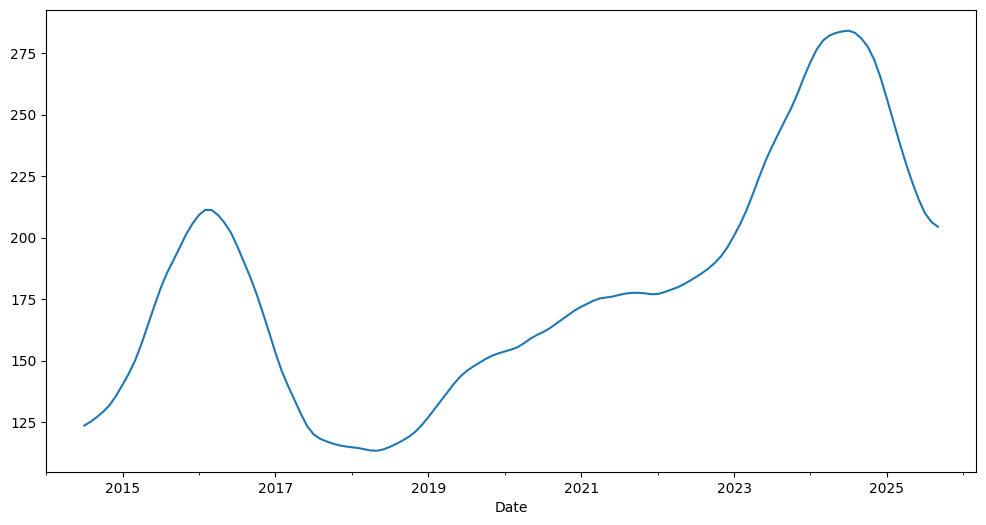

In [324]:
decompose.trend.plot(figsize=(12,6));

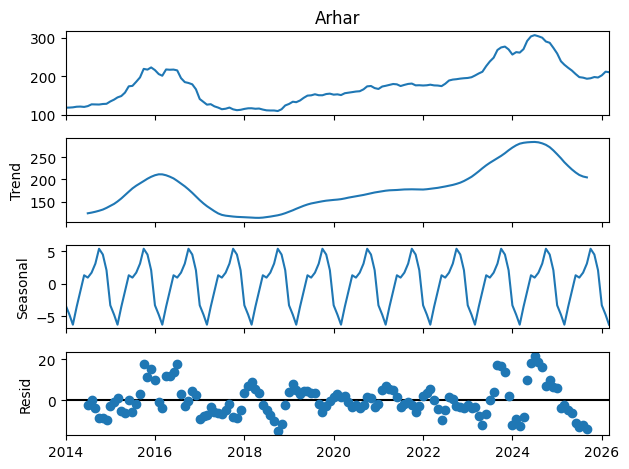

In [325]:
# Plot the decomposition
decompose.plot()
plt.show()

<Axes: >

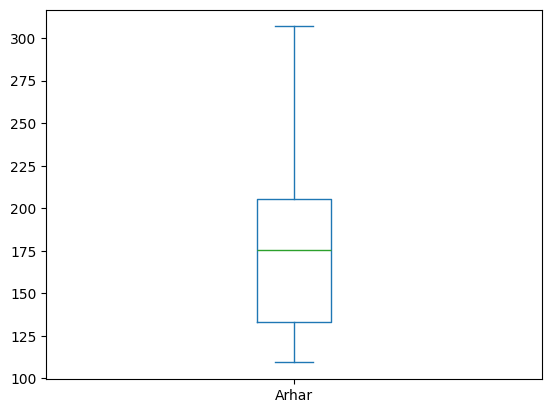

In [326]:
df['Arhar'].plot.box()

# Time series modeling

# Stationarity test

A stationary process has the property that the mean, variance and autocorrelation structure do not change over time.

> $H_0$ : Series is unitroot or non stationary,
>> $H_1$ : Series is stationary

<Axes: xlabel='Date'>

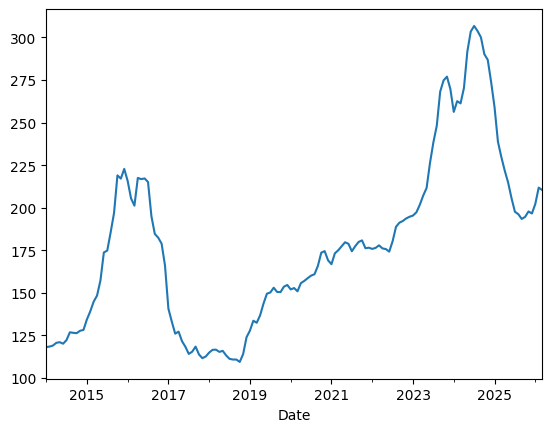

In [327]:
df['Arhar'].plot()

In [328]:
from arch.unitroot import ADF, KPSS, PhillipsPerron

In [329]:
PhillipsPerron(df['Arhar'])

Test Statistic,-1.808
P-value,0.376
Lags,14


In [330]:
ADF(df['Arhar'])

Test Statistic,-1.766
P-value,0.398
Lags,1


#### 1st diff

In [331]:
df_diff = df['Arhar'].diff(periods=1).iloc[1:]

In [332]:
df_diff.head()

,Arhar
Date,
2014-02-01,0.3
2014-03-01,0.6
2014-04-01,1.6
2014-05-01,0.4
2014-06-01,-0.9


In [333]:
PhillipsPerron(df_diff)

Test Statistic,-6.742
P-value,0.000
Lags,14


In [334]:
df_diff.head()

,Arhar
Date,
2014-02-01,0.3
2014-03-01,0.6
2014-04-01,1.6
2014-05-01,0.4
2014-06-01,-0.9


In [335]:
ADF(df_diff)

Test Statistic,-6.341
P-value,0.000
Lags,0


##### In diff. 1, the data series are in stationary.

<Axes: xlabel='Date'>

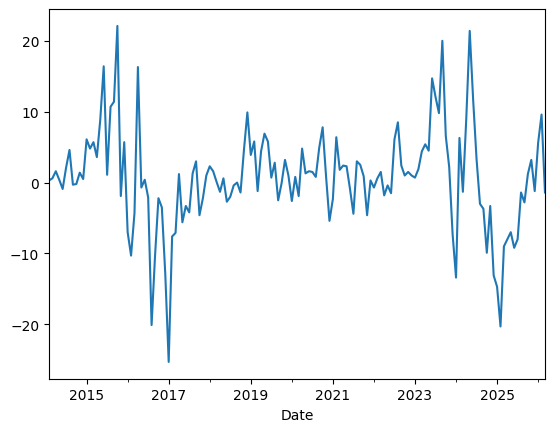

In [336]:
df_diff.plot()

## ACF and PACF plot

>**Autocorrelation** represents the degree of similarity between a given time series and a lagged version of itself over successive time intervals.

> **Partial Autocorrelation** is a conditional correlation.

In [337]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

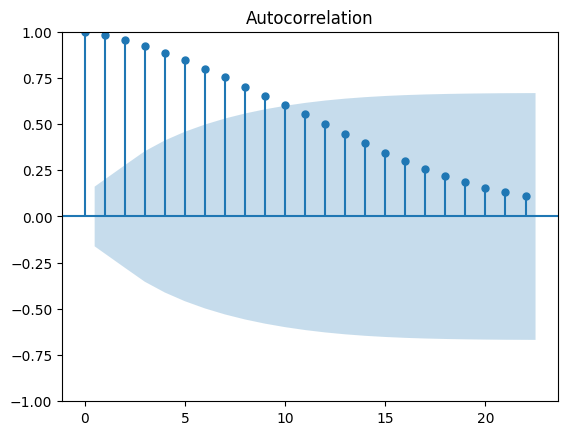

In [338]:
plot_acf(df['Arhar']); # q order

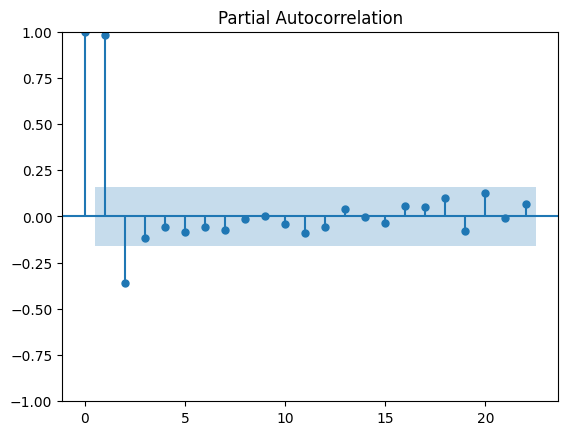

In [339]:
plot_pacf(df['Arhar']); # p order

# AUTO ARIMA

In [340]:
from pmdarima import auto_arima

In [341]:
stepwise_fit = auto_arima(df['Arhar'], start_p=0,start_q=0, max_p=6,max_q=3, m=12, seasonal=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=990.931, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=988.911, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=937.784, Time=0.16 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=955.075, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=988.078, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=936.201, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=937.687, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=939.335, Time=0.31 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=936.959, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=936.985, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=953.346, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=938.309, Time=0.38 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=934.518, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=936.136, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[12]         

In [342]:
stepwise_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  147
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -465.259
Date:                Mon, 20 Apr 2026   AIC                            934.518
Time:                        12:43:15   BIC                            940.485
Sample:                    01-01-2014   HQIC                           936.943
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5604      0.052     10.850      0.000       0.459       0.662
sigma2        34.2247      2.994     11.430      0.000      28.356      40.094
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                18.28
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                            -0.03
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [343]:
from statsmodels.tsa.arima_model import ARIMA, ARIMAResults

In [344]:
from statsmodels.tsa.arima.model import ARIMA

In [345]:
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 147 entries, 2014-01-01 to 2026-03-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gram    147 non-null    float64
 1   Moong   147 non-null    float64
 2   Arhar   147 non-null    float64
dtypes: float64(3)
memory usage: 4.6 KB


In [347]:
train = df.iloc[:132]
test = df.iloc[132:]

In [348]:
len(test)

15

In [349]:
train.tail()

,Gram,Moong,Arhar
Date,,,
2024-08-01,224.1,190.2,303.8
2024-09-01,232.5,192.5,300.1
2024-10-01,230.6,190.9,290.2
2024-11-01,226.7,187.1,286.9
2024-12-01,221.4,186.0,273.8


In [350]:
test.head()

,Gram,Moong,Arhar
Date,,,
2025-01-01,213.7,189.3,259.1
2025-02-01,207.3,188.8,238.8
2025-03-01,203.2,187.2,229.8
2025-04-01,203.6,187.8,221.8
2025-05-01,199.6,187.9,214.8


## ARIMA Model for Gram


ARIMA(p,d,q)

In [351]:
model_gram = ARIMA(train['Arhar'], order=(1,1,0))

result_gram = model_gram.fit()
result_gram.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Arhar   No. Observations:                  132
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -418.667
Date:                Mon, 20 Apr 2026   AIC                            841.334
Time:                        12:43:15   BIC                            847.084
Sample:                    01-01-2014   HQIC                           843.671
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5175      0.059      8.844      0.000       0.403       0.632
sigma2        34.8691      3.157     11.044      0.000      28.681      41.057
===================================================================================
Ljung-Box (L1) (Q):                   0.29   Jarque-Bera (JB):                22.42
Prob(Q):                              0.59   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                            -0.04
Prob(H) (two-sided):                  0.14   Kurtosis:                         5.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [352]:
prediction_gram = result_gram.predict(start=len(train),end=len(train)+len(test)-1, typ='levels').rename('ARIMA(1,1,0)-predictions')

In [353]:
prediction_gram

,"ARIMA(1,1,0)-predictions"
2025-01-01,267.020934
2025-02-01,263.512863
2025-03-01,261.697485
2025-04-01,260.758053
2025-05-01,260.271910
2025-06-01,260.020338
2025-07-01,259.890153
2025-08-01,259.822784
2025-09-01,259.787921
2025-10-01,259.769880


In [354]:
test['ARIMA_prediction']= prediction_gram

<Axes: title={'center': 'True prediction_ARIMA'}, xlabel='Date'>

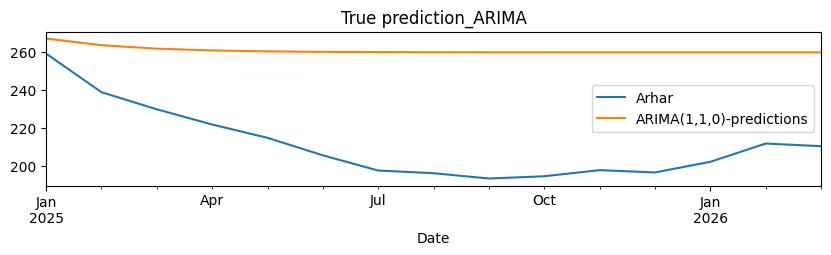

In [355]:
test['Arhar'].plot(figsize=(10,2), legend=True, title='True prediction_ARIMA')
prediction_gram.plot(legend=True)

## Error estimation

In [356]:
from statsmodels.tools.eval_measures import rmse, mse

In [357]:
rmse(test['Arhar'],prediction_gram)

np.float64(52.0866990368576)

In [358]:
mse(test['Arhar'],prediction_gram)

np.float64(2713.0242165561826)

In [359]:
test['Arhar'].mean()

np.float64(211.36666666666667)

In [360]:
prediction_gram.mean()

np.float64(260.75499750635794)

# Final Model Forecasting

In [361]:
FinalModel_gram = ARIMA(df['Arhar'], order=(1,1,0))

FinalResult_gram = FinalModel_gram.fit()

In [362]:
FinalResult_gram.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Arhar   No. Observations:                  147
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -465.259
Date:                Mon, 20 Apr 2026   AIC                            934.518
Time:                        12:43:16   BIC                            940.485
Sample:                    01-01-2014   HQIC                           936.943
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5604      0.052     10.850      0.000       0.459       0.662
sigma2        34.2247      2.994     11.430      0.000      28.356      40.094
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                18.28
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                            -0.03
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [363]:
forecast_gram = FinalResult_gram.predict(start=len(df),end=len(df)+12, typ='levels').rename('ARIMA(1,1,0)-forecast')

<Axes: xlabel='Date'>

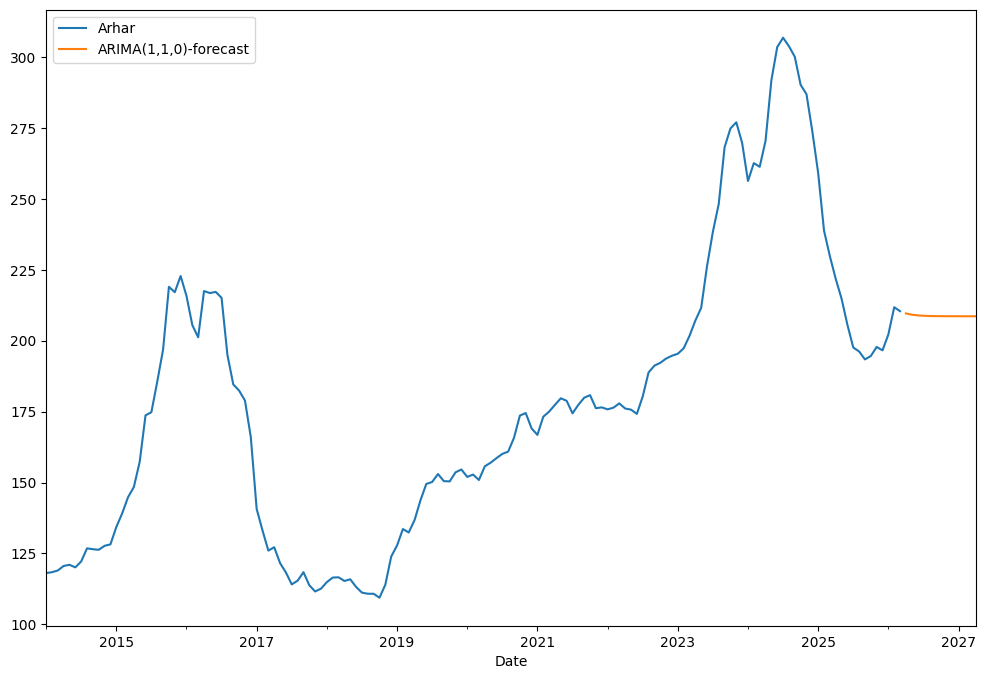

In [364]:
df['Arhar'].plot(figsize=(12,8),legend=True)
forecast_gram.plot(legend=True)

In [365]:
print(forecast_gram)

2026-04-01    209.615398
2026-05-01    209.175684
2026-06-01    208.929256
2026-07-01    208.791150
2026-08-01    208.713751
2026-09-01    208.670374
2026-10-01    208.646065
2026-11-01    208.632441
2026-12-01    208.624806
2027-01-01    208.620527
2027-02-01    208.618129
2027-03-01    208.616785
2027-04-01    208.616032
Freq: MS, Name: ARIMA(1,1,0)-forecast, dtype: float64


# Kolmogorov-Smirnov test for goodness of fit. Normality of residuals

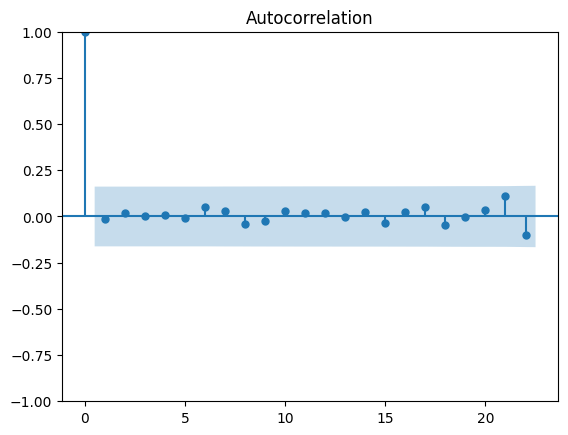

In [366]:
plot_acf(FinalResult_gram.resid);

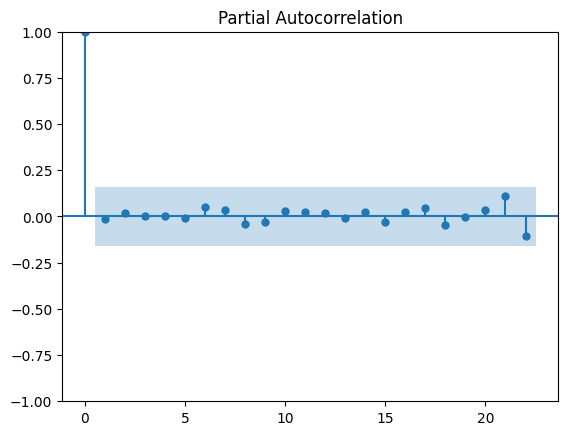

In [367]:
plot_pacf(FinalResult_gram.resid);

<Axes: xlabel='Date'>

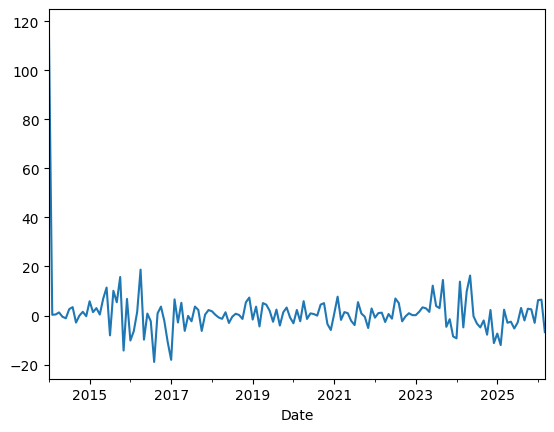

In [368]:
FinalResult_gram.resid.plot()

<Axes: ylabel='Frequency'>

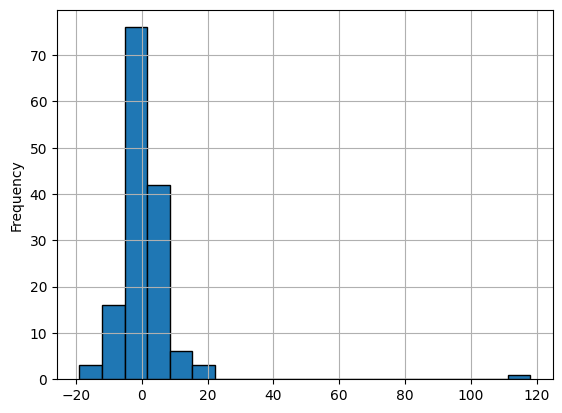

In [369]:
FinalResult_gram.resid.plot.hist(bins=20,grid=True,edgecolor='k')

##### Normality test

In [370]:
stats.kstest(FinalResult_gram.resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.3273597801902136), pvalue=np.float64(1.570814313582854e-14), statistic_location=np.float64(2.2329453502218115), statistic_sign=np.int8(-1))

In [371]:
stats.shapiro(FinalResult_gram.resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.479735255200184), pvalue=np.float64(1.0890570201634312e-20))

In [372]:
from statsmodels.graphics.tsaplots import quarter_plot, month_plot

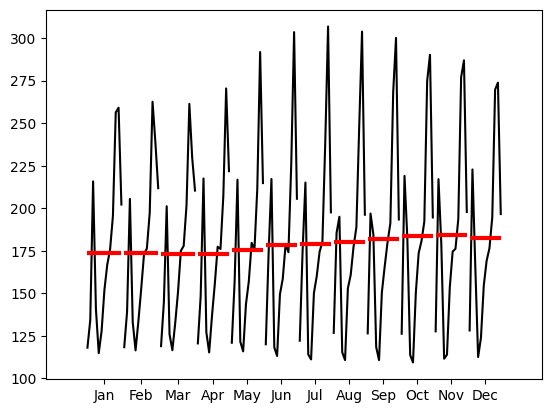

In [373]:
month_plot(df['Arhar']);

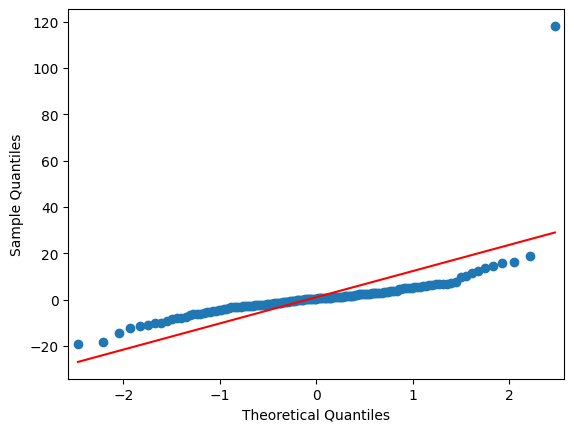

In [374]:
import numpy as np
import statsmodels.api as sm
import pylab


sm.qqplot(FinalResult_gram.resid, line='s');

In [375]:
sm.stats.diagnostic.acorr_ljungbox(FinalResult_gram.resid, lags=[30],return_df=True)

,lb_stat,lb_pvalue
30,12.393467,0.9981


# ARIMA-GARCH

In [376]:
sm.stats.diagnostic.het_arch(FinalResult_gram.resid, nlags=10)

(np.float64(27.167168049756956),
 np.float64(0.002450329529219757),
 3.116611957907184,
 0.001388208217326057)

In [377]:
resid= FinalResult_gram.resid

In [378]:
resid

,0
Date,
2014-01-01,118.100000
2014-02-01,0.296698
2014-03-01,0.431871
2014-04-01,1.263742
2014-05-01,-0.496688
...,...
2025-11-01,2.527484
2025-12-01,-2.993375
2026-01-01,6.272516


In [379]:
resid_train = resid.iloc[:132]
resid_test = resid.iloc[132:]

In [380]:
from arch import arch_model

In [381]:
model_garch = arch_model(resid_train , mean='constant', vol='GARCH', p=1, q=1)
results_garch = model_garch.fit(update_freq = 5)
results_garch.summary()

Iteration:      5,   Func. Count:     31,   Neg. LLF: 426.79833108093544
Iteration:     10,   Func. Count:     56,   Neg. LLF: 426.5240908420326
Optimization terminated successfully    (Exit mode 0)
            Current function value: 426.5240893814415
            Iterations: 12
            Function evaluations: 65
            Gradient evaluations: 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -426.524
Distribution:                  Normal   AIC:                           861.048
Method:            Maximum Likelihood   BIC:                           872.579
                                        No. Observations:                  132
Date:                Mon, Apr 20 2026   Df Residuals:                      131
Time:                        12:43:18   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.6251      0.337      1.853  6.393e-02 [-3.619e-02,  1.286]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          4.7513      2.549      1.864  6.234e-02    [ -0.245,  9.748]
alpha[1]       0.5507      0.287      1.919  5.495e-02 [-1.167e-02,  1.113]
beta[1]        0.4493      0.121      3.715  2.029e-04    [  0.212,  0.686]
===========================================================================

Covariance estimator: robust
"""

In [382]:
resid_test

,0
Date,
2025-01-01,-7.358371
2025-02-01,-12.061683
2025-03-01,2.376723
2025-04-01,-2.956133
2025-05-01,-2.516562
2025-06-01,-5.276992
2025-07-01,-2.844047
2025-08-01,3.083438
2025-09-01,-2.015398


In [383]:
rolling_predictions = []
test_size = 15

for i in range(test_size):
    train = resid[:-(test_size-i)]
    model = arch_model(train, mean='constant', vol='GARCH', p=1, q=1)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [384]:
rolling_predictions = pd.Series(rolling_predictions, index=resid.index[-15:])

In [385]:
rolling_predictions

,0
Date,
2025-01-01,9.833676
2025-02-01,9.071734
2025-03-01,11.413673
2025-04-01,8.038559
2025-05-01,6.353195
2025-06-01,5.271745
2025-07-01,5.934254
2025-08-01,5.139793
2025-09-01,4.482570


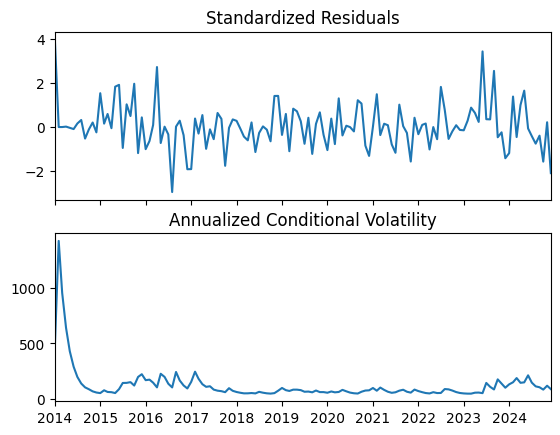

In [386]:
results_garch.plot(annualize='D');

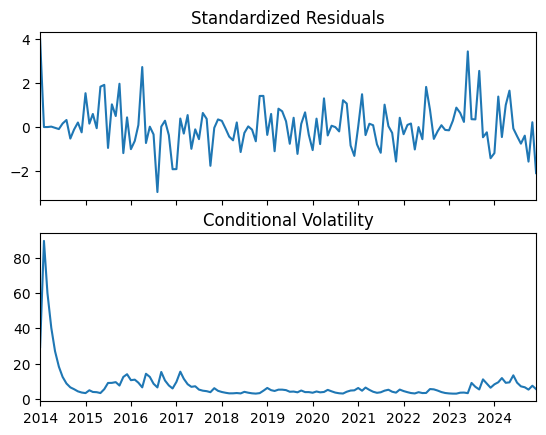

In [387]:
results_garch.plot();

## Normality Check

<Axes: ylabel='Frequency'>

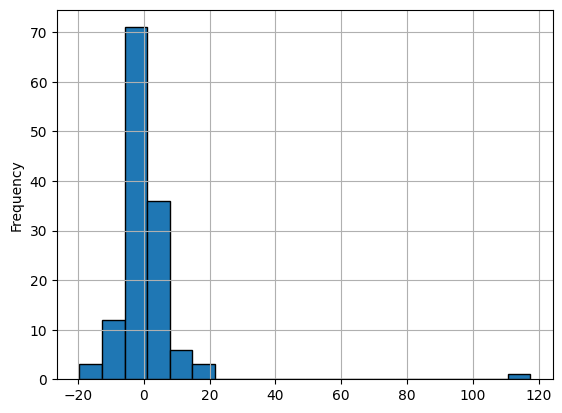

In [388]:
results_garch.resid.plot.hist(bins=20,grid=True,edgecolor='k')

In [389]:
stats.kstest(results_garch.std_resid.values, 'norm') # Kolmogorov-Smirnov test

KstestResult(statistic=np.float64(0.09623073345934263), pvalue=np.float64(0.16246447801020583), statistic_location=np.float64(0.43693507114619634), statistic_sign=np.int8(1))

In [390]:
stats.shapiro(results_garch.std_resid)      # Shapiro wilk test

ShapiroResult(statistic=np.float64(0.9556549479186679), pvalue=np.float64(0.0002810476927623233))

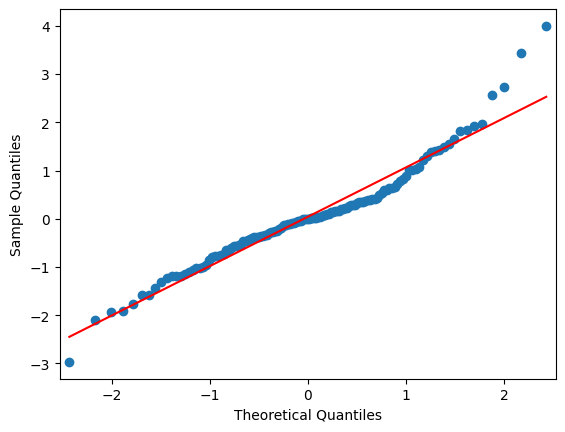

In [391]:
import numpy as np
import statsmodels.api as sm


sm.qqplot(results_garch.std_resid, line='s');

In [392]:
sm.stats.diagnostic.acorr_ljungbox(results_garch.resid, lags=[15], return_df=True)

,lb_stat,lb_pvalue
15,1.485277,0.999996


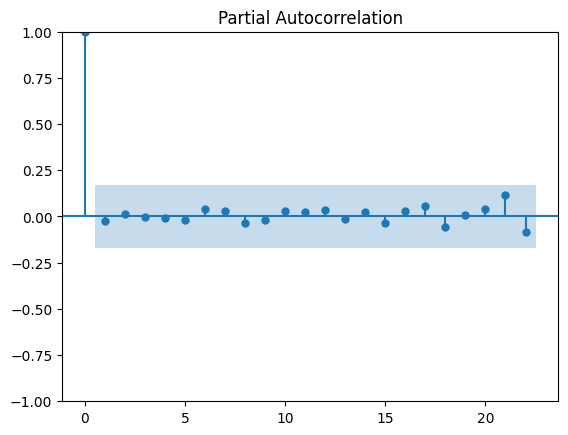

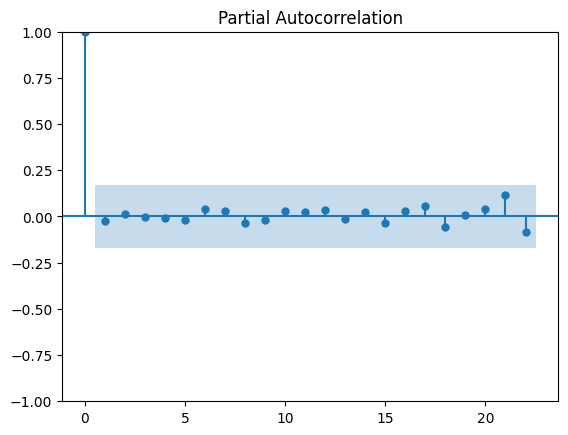

In [393]:
plot_pacf(results_garch.resid)

<Axes: xlabel='Date'>

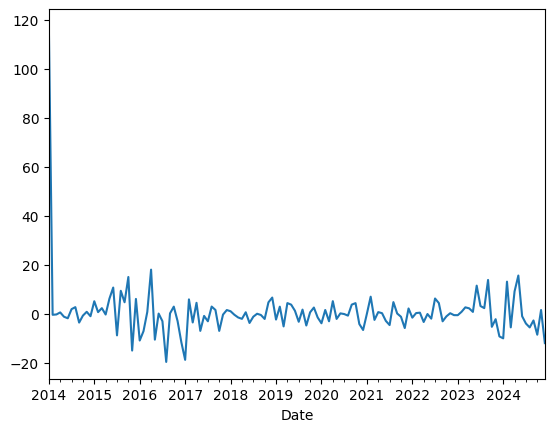

In [394]:
results_garch.resid.plot()

In [395]:
test

,Gram,Moong,Arhar,ARIMA_prediction
Date,,,,
2025-01-01,213.7,189.3,259.1,267.020934
2025-02-01,207.3,188.8,238.8,263.512863
2025-03-01,203.2,187.2,229.8,261.697485
2025-04-01,203.6,187.8,221.8,260.758053
2025-05-01,199.6,187.9,214.8,260.271910
2025-06-01,196.4,184.9,205.6,260.020338
2025-07-01,197.7,183.5,197.6,259.890153
2025-08-01,203.7,186.7,196.2,259.822784
2025-09-01,201.0,187.4,193.4,259.787921


In [396]:
prediction_gram

,"ARIMA(1,1,0)-predictions"
2025-01-01,267.020934
2025-02-01,263.512863
2025-03-01,261.697485
2025-04-01,260.758053
2025-05-01,260.271910
2025-06-01,260.020338
2025-07-01,259.890153
2025-08-01,259.822784
2025-09-01,259.787921
2025-10-01,259.769880


In [397]:
predicted_mu = result_gram.forecast()[0]

In [398]:
predicted_mu

np.float64(267.02093418289354)

In [399]:
garch_forecast = results_garch.forecast(horizon=1)

In [400]:
predicted_et = garch_forecast.mean['h.1'].iloc[-1]

In [401]:
predicted_et

np.float64(0.6251083520301619)

In [402]:
prediction = predicted_mu+predicted_et

In [403]:
prediction_GARCH = prediction_gram+rolling_predictions

In [404]:
prediction_GARCH

,0
2025-01-01,276.854610
2025-02-01,272.584597
2025-03-01,273.111159
2025-04-01,268.796612
2025-05-01,266.625105
2025-06-01,265.292083
2025-07-01,265.824407
2025-08-01,264.962576
2025-09-01,264.270491
2025-10-01,263.895390


In [405]:
rmse(test['Arhar'],prediction_GARCH)

np.float64(57.454707496840335)

In [406]:
prediction_GARCH.shape

(15,)

In [407]:
test['Arhar'].shape

(15,)

In [408]:
prediction_gram.shape

(15,)

In [409]:
mse(test['Arhar'],prediction_GARCH)

np.float64(3301.0434135474807)

In [410]:
!pip install diebold_mariano_test

In [411]:
from diebold_mariano_test import cul_d_t,MAE,MSE,cul_DM,cul_P

In [412]:
dm = cul_d_t(MAE,test['Arhar'],prediction_gram,prediction_GARCH)

In [413]:
cul_DM(dm)

np.float64(-10.494263599172523)

In [414]:
cul_P(dm)

np.float64(9.179064283256272e-26)

In [415]:
MAE(3,test['Arhar'],prediction_gram)

np.float64(31.897485386256108)

In [416]:
dm1=cul_d_t(MAE,test['Arhar'],prediction_GARCH,prediction_gram)

In [417]:
cul_DM(dm1)

np.float64(10.494263599172523)

In [418]:
test['GARCH_prediction']= prediction_GARCH

# ARIMA-LSTM

### Lag estimation

In [419]:
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot
from pandas import DataFrame

In [420]:
acf(FinalResult_gram.resid**2,nlags=12,qstat=True)

(array([ 1.00000000e+00, -1.89833468e-03, -2.35301128e-03, -1.78024011e-03,
        -1.67544608e-03, -1.70580125e-03, -2.06228255e-03, -1.88231338e-03,
        -1.74730866e-03, -2.19455479e-03, -2.51008570e-03, -3.17666771e-03,
        -8.22368559e-04]),
 array([0.00054063, 0.00137697, 0.00185902, 0.00228898, 0.0027378 ,
        0.00339847, 0.00395279, 0.00443388, 0.00519827, 0.00620558,
        0.00783078, 0.00794051]),
 array([0.98144978, 0.99931175, 0.99997869, 0.99999935, 0.99999998,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        ]))

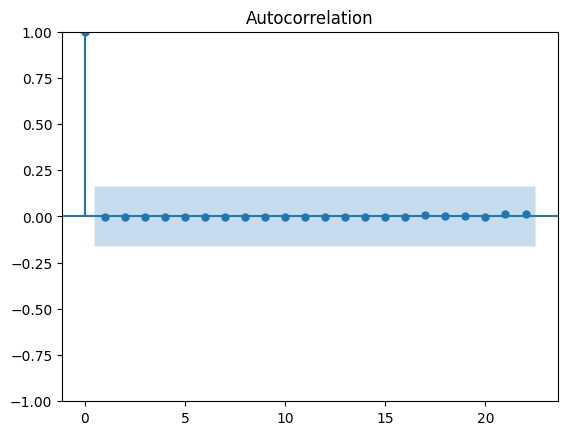

In [421]:
plot_acf(FinalResult_gram.resid**2);

In [422]:
df['resid'] = FinalResult_gram.resid**2

In [423]:
df

,Gram,Moong,Arhar,resid
Date,,,,
2014-01-01,103.6,126.5,118.1,13947.610000
2014-02-01,101.7,129.3,118.4,0.088030
2014-03-01,103.5,132.6,119.0,0.186513
2014-04-01,102.8,135.5,120.6,1.597044
2014-05-01,103.1,137.8,121.0,0.246698
...,...,...,...,...
2025-11-01,196.1,188.1,197.8,6.388177
2025-12-01,191.6,188.5,196.6,8.960294
2026-01-01,191.5,189.8,202.2,39.344453


In [424]:
mylist= ['resid']

df1 = df[mylist][1:]
df1.head()

,resid
Date,
2014-02-01,0.088030
2014-03-01,0.186513
2014-04-01,1.597044
2014-05-01,0.246698
2014-06-01,1.263762


In [425]:
dataframe = DataFrame()
for i in range(9,0,-1):
    dataframe['t-'+str(i)] = df1.shift(i).values[:,0]
dataframe['t'] = df1.values[:,0]
print(dataframe.head(10))
dataframe = dataframe[10:]

       t-9       t-8       t-7       t-6       t-5       t-4        t-3  \
0      NaN       NaN       NaN       NaN       NaN       NaN        NaN   
1      NaN       NaN       NaN       NaN       NaN       NaN        NaN   
2      NaN       NaN       NaN       NaN       NaN       NaN        NaN   
3      NaN       NaN       NaN       NaN       NaN       NaN   0.088030   
4      NaN       NaN       NaN       NaN       NaN  0.088030   0.186513   
5      NaN       NaN       NaN       NaN  0.088030  0.186513   1.597044   
6      NaN       NaN       NaN  0.088030  0.186513  1.597044   0.246698   
7      NaN       NaN  0.088030  0.186513  1.597044  0.246698   1.263762   
8      NaN  0.088030  0.186513  1.597044  0.246698  1.263762   6.782830   
9  0.08803  0.186513  1.597044  0.246698  1.263762  6.782830  11.717597   

         t-2        t-1          t  
0        NaN        NaN   0.088030  
1        NaN   0.088030   0.186513  
2   0.088030   0.186513   1.597044  
3   0.186513   1.597044   

In [426]:
dataframe.to_csv('lags_12months_features.csv', index=False)

In [427]:
dataframe = pd.read_csv('lags_12months_features.csv', header=0)
array = dataframe.values

In [428]:
X = array[:,0:-1]
y = array[:,-1]

In [429]:
model = RandomForestRegressor(n_estimators=100, random_state=1)
model.fit(X, y)

RandomForestRegressor(random_state=1)

In [430]:
print(model.feature_importances_)

[0.08937117 0.11061645 0.06265191 0.08464281 0.18967234 0.17625366
 0.15954795 0.04610232 0.08114139]


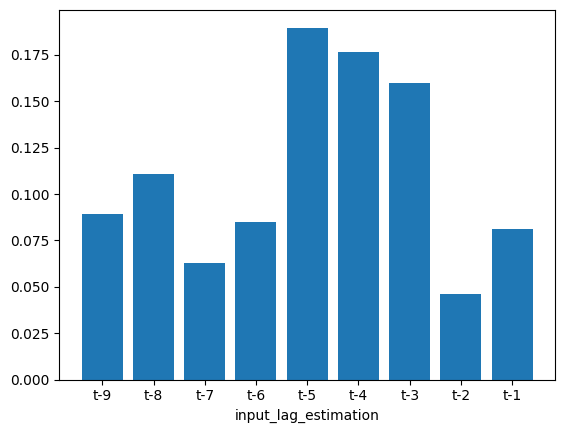

In [431]:
names = dataframe.columns.values[0:-1]
ticks = [i for i in range(len(names))]
pyplot.bar(ticks, model.feature_importances_)
pyplot.xticks(ticks, names)
pyplot.xlabel('input_lag_estimation')
pyplot.show()

In [432]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 146 entries, 2014-02-01 to 2026-03-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   resid   146 non-null    float64
dtypes: float64(1)
memory usage: 2.3 KB


In [462]:
train_resid = df1.iloc[:131]
test_resid = df1.iloc[131:]

In [463]:
train_resid

,resid
Date,
2014-02-01,0.088030
2014-03-01,0.186513
2014-04-01,1.597044
2014-05-01,0.246698
2014-06-01,1.263762
...,...
2024-08-01,23.516855
2024-09-01,4.075194
2024-10-01,61.252695


In [464]:
test_resid

,resid
Date,
2025-01-01,54.145622
2025-02-01,145.484205
2025-03-01,5.648812
2025-04-01,8.738720
2025-05-01,6.333086
2025-06-01,27.846645
2025-07-01,8.088602
2025-08-01,9.507588
2025-09-01,4.061831


In [465]:
from sklearn.preprocessing import MinMaxScaler

In [466]:
scaler = MinMaxScaler()
scaler.fit(train_resid)

MinMaxScaler()

In [467]:
scaled_train = scaler.transform(train_resid)
scaled_test = scaler.transform(test_resid)

In [468]:
scaled_test

array([[0.15120703],
       [0.40628387],
       [0.01577233],
       [0.02440137],
       [0.01768327],
       [0.07776314],
       [0.02258581],
       [0.02654854],
       [0.01134044],
       [0.02141257],
       [0.01783712],
       [0.02502014],
       [0.10987252],
       [0.11659649],
       [0.12837563]])

In [469]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [470]:
# Define the generator
n_input = 1 # how many data will estimate the next time stand value.
n_features = 1

train_generator = TimeseriesGenerator(scaled_train,scaled_train,length=n_input,batch_size=1)

In [471]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.utils import plot_model

In [472]:
model = Sequential()

model.add(LSTM(66, activation='relu', input_shape =(n_input,n_features)))    #relu = rectified linear unit
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

In [473]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 66)             │        17,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            67 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,019 (70.39 KB)

 Trainable params: 18,019 (70.39 KB)

 Non-trainable params: 0 (0.00 B)

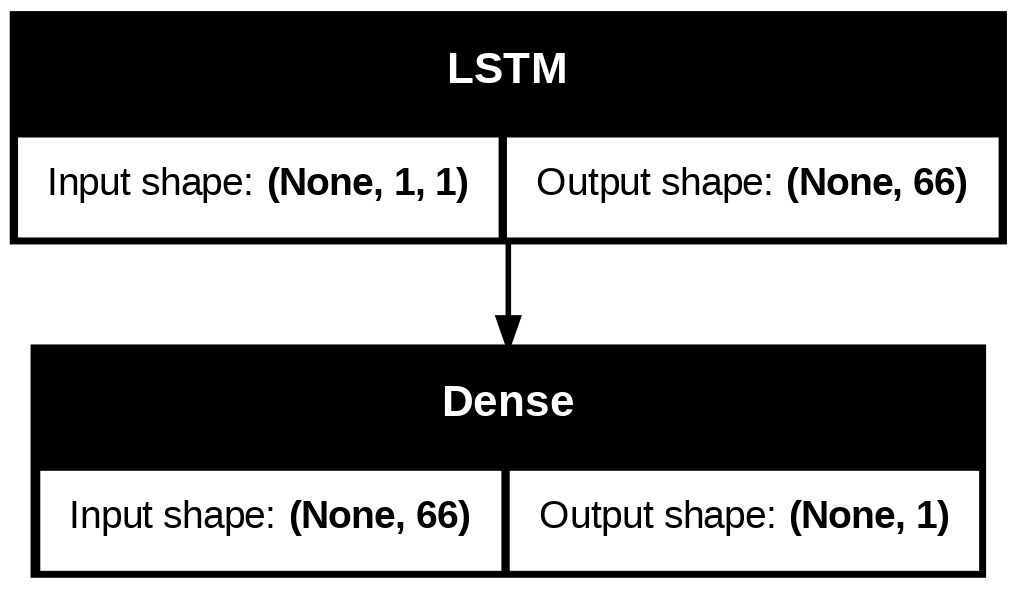

In [474]:
plot_model(model,show_shapes=True)

In [475]:
model.fit(train_generator, epochs=25)

Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0388
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0363
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0363
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0361
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0362
Epoch 6/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0365
Epoch 7/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0361
Epoch 8/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0360
Epoch 9/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0360
Epoch 10/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0359
Epoch 11/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0359
Epoch 12/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0359
Epoch 13/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0361
Epoch 14/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0359
Epoch 15/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

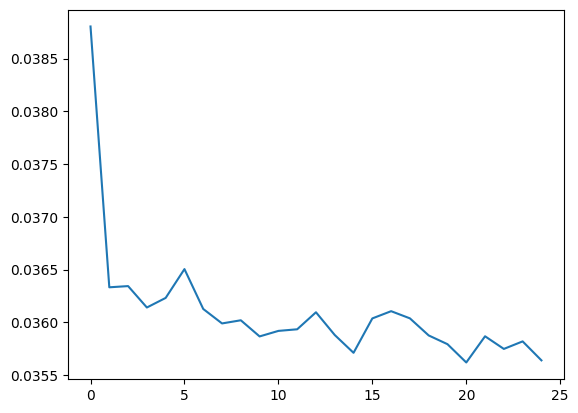

In [476]:
myloss = model.history.history['loss']

plt.plot(range(len(myloss)),myloss)

In [477]:
# Holding my prediction
test_prediction = []

# Last n_input point from the train set
first_eval_batch= scaled_train[-n_input:]

# Reshape this to the RNN format. same as TimeSeriesGenarator
current_batch = first_eval_batch.reshape((1,n_input,n_features))

# How far will we forecast?

for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]

    test_prediction.append(current_pred)

    current_batch= np.append(current_batch[:,1:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [478]:
test_prediction

[array([0.16123073], dtype=float32),
 array([0.12029031], dtype=float32),
 array([0.11101289], dtype=float32),
 array([0.10891058], dtype=float32),
 array([0.10843417], dtype=float32),
 array([0.10832623], dtype=float32),
 array([0.10830176], dtype=float32),
 array([0.10829622], dtype=float32),
 array([0.10829496], dtype=float32),
 array([0.10829468], dtype=float32),
 array([0.10829462], dtype=float32),
 array([0.10829461], dtype=float32),
 array([0.10829461], dtype=float32),
 array([0.10829461], dtype=float32),
 array([0.10829461], dtype=float32)]

In [479]:
true_prediction = scaler.inverse_transform(test_prediction)

In [480]:
true_prediction = true_prediction[:15]


In [481]:
test_resid['resid']

,resid
Date,
2025-01-01,54.145622
2025-02-01,145.484205
2025-03-01,5.648812
2025-04-01,8.738720
2025-05-01,6.333086
2025-06-01,27.846645
2025-07-01,8.088602
2025-08-01,9.507588
2025-09-01,4.061831


In [482]:
test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'] = true_prediction

In [483]:
test_resid['Prediction Volatility ARIMA-GARCH']= rolling_predictions
test_resid['true Volatility']= resid_test
test_resid.to_csv('Gram volatility.csv')

In [484]:
test['ARIMA-LSTM_Pred']= test['ARIMA_prediction']+test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)']

In [485]:
test

,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,267.020934,276.854610,324.755869
2025-02-01,207.3,188.8,238.8,263.512863,272.584597,306.587746
2025-03-01,203.2,187.2,229.8,261.697485,273.111159,301.450287
2025-04-01,203.6,187.8,221.8,260.758053,268.796612,299.758052
2025-05-01,199.6,187.9,214.8,260.271910,266.625105,299.101316
2025-06-01,196.4,184.9,205.6,260.020338,265.292083,298.811091
2025-07-01,197.7,183.5,197.6,259.890153,265.824407,298.672145
2025-08-01,203.7,186.7,196.2,259.822784,264.962576,298.602791
2025-09-01,201.0,187.4,193.4,259.787921,264.270491,298.567480


In [486]:
test2=test = test.dropna(subset=['ARIMA-LSTM_Pred'])

test2


,Gram,Moong,Arhar,ARIMA_prediction,GARCH_prediction,ARIMA-LSTM_Pred
Date,,,,,,
2025-01-01,213.7,189.3,259.1,267.020934,276.854610,324.755869
2025-02-01,207.3,188.8,238.8,263.512863,272.584597,306.587746
2025-03-01,203.2,187.2,229.8,261.697485,273.111159,301.450287
2025-04-01,203.6,187.8,221.8,260.758053,268.796612,299.758052
2025-05-01,199.6,187.9,214.8,260.271910,266.625105,299.101316
2025-06-01,196.4,184.9,205.6,260.020338,265.292083,298.811091
2025-07-01,197.7,183.5,197.6,259.890153,265.824407,298.672145
2025-08-01,203.7,186.7,196.2,259.822784,264.962576,298.602791
2025-09-01,201.0,187.4,193.4,259.787921,264.270491,298.567480


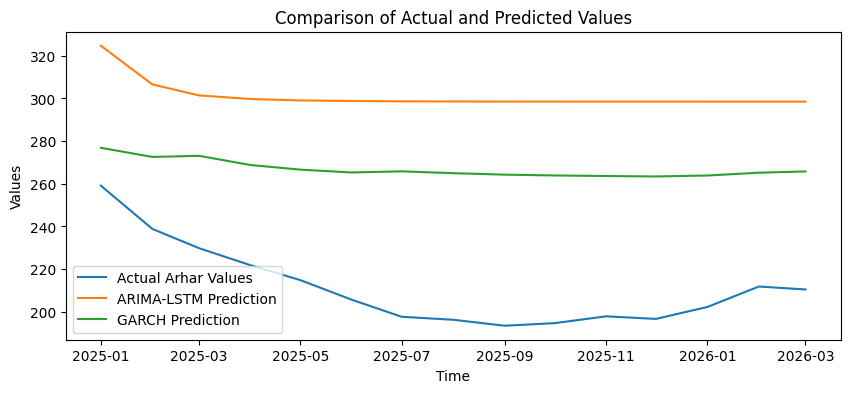

In [487]:
plt.figure(figsize=(10, 4))
plt.plot(test['Arhar'], label='Actual Arhar Values')
plt.plot(test['ARIMA-LSTM_Pred'], label='ARIMA-LSTM Prediction')
plt.plot(test['GARCH_prediction'], label='GARCH Prediction')

# Adding labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Comparison of Actual and Predicted Values")
plt.legend()
plt.show()

In [488]:
rmse(test['Arhar'],test['ARIMA-LSTM_Pred'])

np.float64(90.77015883432468)

In [489]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [490]:
mean_absolute_percentage_error(test['Arhar'],test['ARIMA-LSTM_Pred'])

np.float64(43.26887280101438)

In [491]:
test.to_csv('Gram_result with ARIMA-LSTM Random forecst.csv')

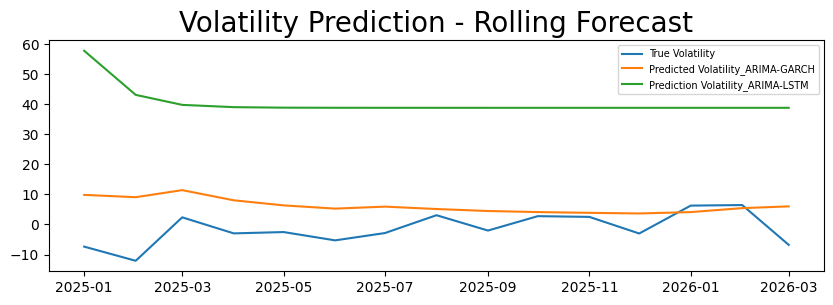

In [492]:
plt.figure(figsize=(10,3))
true, = plt.plot(resid_test)
preds, = plt.plot(rolling_predictions)
pred, = plt.plot(test_resid['prediction Volatility ARIMA-LSTM(Random_Forest)'])
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility_ARIMA-GARCH','Prediction Volatility_ARIMA-LSTM'], fontsize=7)